# Content Validity Analysis Using Aiken’s V

This notebook performs a full analysis of content validity based on expert judgment, using **Aiken’s V coefficient** and its 95% confidence interval. The dataset includes expert ratings on educational items categorized under two content dimensions: **Relevance** and **Wording**.



In [1]:
# ==========================================================================
# Install dependencies (safe to re-run; Colab usually has most of these)
# ==========================================================================
!pip install -q python-docx tabulate


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
# ==========================================================================
# Load libraries and import CSV files
# ==========================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from IPython.display import display, Markdown

# Load datasets from Google Drive
df = pd.read_csv('../data/expert_judgment/sociodemographic_judges.csv')
df2 = pd.read_csv('../data/expert_judgment/data_aiken_engagement.csv')


## 👤 Expert Judges Characterization

In [3]:
import pandas as pd
from tabulate import tabulate

# Total number of participants
n = len(df)

# List where the summary table will be built
summary_table = []

# Function to add categorical blocks
def add_block(variable, variable_name):
    summary_table.append([f"**{variable_name}**", "", ""])
    counts = df[variable].value_counts().sort_index()
    for category, freq in counts.items():
        percentage = round((freq / n) * 100, 1)
        summary_table.append(["", f"{category}", f"{freq} ({percentage}%)"])

# Blocks of categorical variables
add_block("sexo", "Sex")
add_block("grado_academico", "Highest academic degree")
add_block("Area_OCDE", "OCDE Area")
add_block("experiencia_profesional", "Type of (main) professional experience")

# Numeric variable block: years of experience
summary_table.append(["**Years of experience**", "", ""])
summary_table.append(["", "Median (Q1, Q3)", f"{df['anios_experiencia'].median()} ({df['anios_experiencia'].quantile(0.25)}, {df['anios_experiencia'].quantile(0.75)})"])
summary_table.append(["", "Mean (SD)", f"{round(df['anios_experiencia'].mean(),1)} ({round(df['anios_experiencia'].std(),1)})"])
summary_table.append(["", "Min, Max", f"{df['anios_experiencia'].min()}, {df['anios_experiencia'].max()}"])

# Experience in instrument validation
add_block("exp_valid_inst", "Do you have experience in instrument validation?")

# Create final DataFrame
table_df = pd.DataFrame(summary_table, columns=["Variable", "Category", f"n={n}"])

# Display as Markdown table (without index)
print("### Table 3. Characterization of expert judges\n")
print(tabulate(table_df, headers="keys", tablefmt="github", showindex=False))

### Table 3. Characterization of expert judges

| Variable                                             | Category                       | n=24                |
|------------------------------------------------------|--------------------------------|---------------------|
| **Sex**                                              |                                |                     |
|                                                      | Femenino                       | 9 (37.5%)           |
|                                                      | Masculino                      | 15 (62.5%)          |
| **Highest academic degree**                          |                                |                     |
|                                                      | Doctorado                      | 24 (100.0%)         |
| **OCDE Area**                                        |                                |                     |
|                                                      |

## 🧮 Statistical Functions: Aiken’s V and Confidence Intervals

In [4]:
def compute_aiken_v(values, k):
    """
    Compute Aiken's V coefficient for content validity.

    Parameters:
    - values: array-like, expert ratings for a given item (e.g., integers from 1 to k)
    - k: int, maximum value of the rating scale (e.g., 4 for a 4-point Likert scale)

    Returns:
    - V: float, Aiken's V coefficient
    """
    N = len(values)  # Number of expert raters
    V = sum(values - 1) / (N * (k - 1))  # Aiken's formula
    return V

def compute_aiken_ci(V, n, k, confidence=0.95):
    """
    Compute the confidence interval for Aiken's V using the formula by Penfield & Giacobbi (2004).

    Parameters:
    - V: float, Aiken's V value
    - n: int, number of raters
    - k: int, number of points on the rating scale
    - confidence: float, desired confidence level (default = 0.95)

    Returns:
    - (L, U): tuple of floats, lower and upper bounds of the confidence interval
    """
    z = norm.ppf(1 - (1 - confidence) / 2)  # Z-score for the specified confidence level

    # Intermediate term inside the square root of the CI formula
    sqrt_term = np.sqrt(4 * n * k * V * (1 - V) + z**2)

    # Compute lower (L) and upper (U) bounds of the confidence interval
    L = (2 * n * k * V + z**2 - z * sqrt_term) / (2 * (n * k + z**2))
    U = (2 * n * k * V + z**2 + z * sqrt_term) / (2 * (n * k + z**2))

    return (L, U)

## 📊 Aiken’s V Calculation by Item

In [5]:
import pandas as pd
import numpy as np
from scipy.stats import norm
from IPython.display import display, Markdown

# Reshape the dataset to long format for item-level analysis
lf2 = df2.melt(id_vars='dimension', var_name='item', value_name='valor')

# Define number of response options on the rating scale (e.g., 4-point scale)
k = 4

# Confidence level for interval estimation
confianza = 0.95

# Compute mean and number of raters per item-dimension combination
resultados = (
    lf2.groupby(['dimension', 'item'])
    .agg(promedio=('valor', 'mean'), n=('valor', 'count'))  # mean rating and number of raters
    .reset_index()
)

# Calculate Aiken’s V for each item
resultados['V'] = lf2.groupby(['dimension', 'item'])['valor'].apply(lambda x: compute_aiken_v(x.values, k)).values

# Compute confidence intervals for Aiken’s V
resultados[['lim_inf', 'lim_sup']] = resultados.apply(
    lambda row: pd.Series(compute_aiken_ci(row['V'], row['n'], k, confianza)), axis=1
)

# Generate frequency counts for each response value (1–4) per item
frecuencias = (
    lf2.groupby(['dimension', 'item', 'valor'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=range(1, k + 1), fill_value=0) # Ensure all columns from 1 to k are present
    .reset_index()
)

# Merge frequencies with Aiken’s V results into one final table
resultados_final = pd.merge(resultados, frecuencias, on=['dimension', 'item'], how='left').fillna(0)

# Reorder columns for presentation: dimension, item, frequencies, mean, V, CI
cols_order = ['dimension', 'item', 1, 2, 3, 4, 'promedio', 'V', 'lim_inf', 'lim_sup']
resultados_final = resultados_final[cols_order]

# Round numeric results to 3 decimal places
resultados_final[['promedio', 'V', 'lim_inf', 'lim_sup']] = resultados_final[['promedio', 'V', 'lim_inf', 'lim_sup']].round(3)

# Display final results table
display(Markdown("### Final results of Aiken’s V analysis"))
display(resultados_final)


### Final results of Aiken’s V analysis

,dimension,item,1,2,3,4,promedio,V,lim_inf,lim_sup
0,relevance,item01,1,1,7,15,3.500,0.833,0.746,0.895
1,relevance,item02,0,2,0,22,3.833,0.944,0.879,0.975
2,relevance,item03,0,1,3,20,3.792,0.931,0.861,0.967
3,relevance,item04,0,0,6,18,3.750,0.917,0.844,0.957
4,relevance,item05,1,3,5,15,3.417,0.806,0.715,0.872
...,...,...,...,...,...,...,...,...,...,...
57,wording,item27,0,0,6,18,3.750,0.917,0.844,0.957
58,wording,item28,0,3,4,17,3.583,0.861,0.778,0.916
59,wording,item29,0,0,4,20,3.833,0.944,0.879,0.975
60,wording,item30,0,0,3,21,3.875,0.958,0.898,0.984


## 📈 Visualization of Aiken’s V and Confidence Intervals

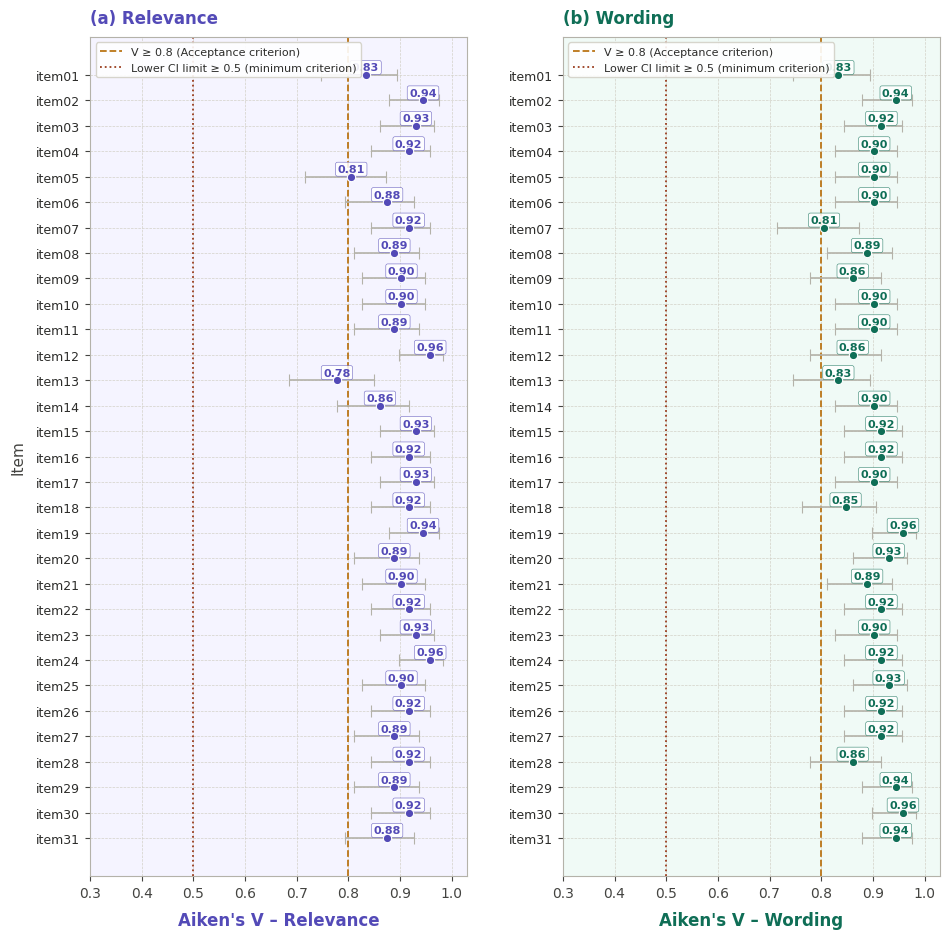

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Dimension titles in English
titulo_dim = {
    'relevance': 'Relevance',
    'wording': 'Wording'
}

# Color palette (publication-quality, colorblind-friendly)
COLOR_RELEVANCE = '#534AB7'   # Purple for relevance panel
COLOR_WORDING   = '#0F6E56'   # Teal for wording panel
COLOR_THRESHOLD = '#BA7517'   # Amber for acceptance threshold line
COLOR_MIN       = '#993C1D'   # Coral for minimum CI line
COLOR_PANEL_BG  = ['#F5F4FF', '#F0FAF6']  # Subtle tinted backgrounds

# Update matplotlib defaults
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.edgecolor':   '#444441',
    'xtick.color':      '#444441',
    'ytick.color':      '#444441',
    'text.color':       '#2C2C2A',
    'axes.labelcolor':  '#2C2C2A',
    'axes.grid':        True,
    'grid.color':       '#D3D1C7',
    'grid.linewidth':   0.5,
    'grid.linestyle':   '--',
    'axes.axisbelow':   True,
})

# Panel colors per dimension
panel_colors = {
    'relevance': COLOR_RELEVANCE,
    'wording':   COLOR_WORDING
}
panel_bg = {
    'relevance': COLOR_PANEL_BG[0],
    'wording':   COLOR_PANEL_BG[1]
}

# Create figure with 2 side-by-side subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(9.6, 9.5), sharex=False)

for ax, dimension in zip(axes, ['relevance', 'wording']):
    color = panel_colors[dimension]

    # Filter and prepare data
    subset = resultados[resultados['dimension'] == dimension].copy()
    subset = subset.reset_index(drop=True)
    subset['y_pos'] = subset.index

    # Tinted panel background
    ax.set_facecolor(panel_bg[dimension])

    # Error bars with panel color
    ax.errorbar(
        subset['V'], subset['y_pos'],
        xerr=[subset['V'] - subset['lim_inf'], subset['lim_sup'] - subset['V']],
        fmt='o',
        color=color,
        ecolor='#B4B2A9',
        elinewidth=1.2,
        capsize=4,
        markersize=6,
        markerfacecolor=color,
        markeredgecolor='white',
        markeredgewidth=0.8,
        zorder=3
    )

    # Acceptance criterion line (V ≥ 0.8) — amber dashed
    ax.axvline(
        0.8, color=COLOR_THRESHOLD, linestyle='--', linewidth=1.3,
        label='V ≥ 0.8 (Acceptance criterion)',
        zorder=2
    )

    # Minimum lower CI limit (≥ 0.5) — coral dotted
    ax.axvline(
        0.5, color=COLOR_MIN, linestyle=':', linewidth=1.3,
        label='Lower CI limit ≥ 0.5 (minimum criterion)',
        zorder=2
    )

    # Value labels with subtle tinted background
    for _, row in subset.iterrows():
        ax.text(
            row['V'], row['y_pos'] - 0.18,
            f"{row['V']:.2f}",
            ha='center', fontsize=8,
            color=color, weight='bold',
            bbox=dict(
                facecolor='white',
                edgecolor=color,
                linewidth=0.4,
                boxstyle='round,pad=0.18',
                alpha=0.85
            )
        )

    # Y-axis: item labels
    ax.set_yticks(subset['y_pos'])
    ax.set_yticklabels(subset['item'], fontsize=9, color='#2C2C2A')
    ax.invert_yaxis()

    # X-axis label with panel color accent
    ax.set_xlabel(
        f"Aiken's V – {titulo_dim[dimension]}",
        fontsize=12, color=color, weight='bold', labelpad=8
    )

    # Y-axis label only on left panel
    if dimension == 'relevance':
        ax.set_ylabel("Item", fontsize=11, color='#444441', labelpad=8)
    else:
        ax.set_ylabel("")

    # X-axis limits
    x_max = max(subset['lim_sup'].max(), 1.0) + 0.03
    ax.set_xlim(0.3, x_max)

    # Spine styling
    for spine in ax.spines.values():
        spine.set_edgecolor('#B4B2A9')
        spine.set_linewidth(0.8)

    # Panel title
    panel_label = '(a)' if dimension == 'relevance' else '(b)'
    ax.set_title(
        f"{panel_label} {titulo_dim[dimension]}",
        fontsize=12, color=color, weight='bold', pad=10, loc='left'
    )

    # Legend
    ax.legend(
        loc='upper left', fontsize=8,
        frameon=True,
        framealpha=0.9,
        edgecolor='#D3D1C7',
        facecolor='white'
    )


plt.tight_layout(w_pad=3)

# Export in high resolution
plt.savefig("../outputs/figures/Figure2_Aiken_V.pdf", format='pdf', bbox_inches='tight')
plt.savefig("../outputs/figures/Figure2_Aiken_V.png", format='png', dpi=600, bbox_inches='tight')
plt.savefig("../outputs/figures/Figure2_Aiken_V.tiff", format='tiff', dpi=600, bbox_inches='tight')

plt.show()

### 📌 Reproducibility Notes

- Designed for execution in [Google Colab](https://colab.research.google.com/).
- Required Python libraries: `pandas`, `numpy`, `matplotlib`, `scipy`, `seaborn`.
- Make sure the repository includes both the `.ipynb` notebook and the corresponding `.csv` data files for full reproducibility.

---

© 2025 – Ricardo Monge.  
This work is licensed under the [MIT License](https://opensource.org/licenses/MIT).


## 📝 Export to Word (APA7)

The cells below collect the **judges' characterization table**, the **Aiken's V results table**, and the **forest-plot figure** into a single Word document formatted according to **APA 7th edition** (bold table/figure numbers, italic titles in title case, horizontal rules only, and italic `Note.` lines). The file is saved to the Colab session, optionally copied to Google Drive, and downloaded to your computer.

In [7]:
# ==========================================================================
# APA7 Word export — helper functions
# ==========================================================================
# These build APA7-style content inside a python-docx Document:
#   - Tables:  bold "Table N", italic title (title case), horizontal rules
#              only (top of header / below header / bottom of table),
#              italic "Note." line below.
#   - Figures: bold "Figure N", italic title, centered image, italic "Note.".

from docx.shared import Pt, Inches
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.oxml.ns import qn
from docx.oxml import OxmlElement

APA_FONT = "Times New Roman"
APA_BODY_SIZE = 11
APA_TABLE_SIZE = 10


def _set_cell_border(cell, **kwargs):
    """Apply/remove borders on one cell. Keys: top/bottom/left/right ->
    dict(val='single'|'nil', sz=.., color='000000', space=0)."""
    tcPr = cell._tc.get_or_add_tcPr()
    borders = tcPr.find(qn('w:tcBorders'))
    if borders is None:
        borders = OxmlElement('w:tcBorders')
        tcPr.append(borders)
    for edge in ('top', 'bottom', 'left', 'right'):
        if edge in kwargs:
            el = borders.find(qn(f'w:{edge}'))
            if el is None:
                el = OxmlElement(f'w:{edge}')
                borders.append(el)
            for k, v in kwargs[edge].items():
                el.set(qn(f'w:{k}'), str(v))


def _no_borders(cell):
    _set_cell_border(cell, top={'val': 'nil'}, bottom={'val': 'nil'},
                     left={'val': 'nil'}, right={'val': 'nil'})


def _style_run(run, bold=False, italic=False, size=APA_BODY_SIZE, font=APA_FONT):
    run.bold = bold
    run.italic = italic
    run.font.size = Pt(size)
    run.font.name = font
    rPr = run._element.get_or_add_rPr()
    rFonts = rPr.find(qn('w:rFonts'))
    if rFonts is None:
        rFonts = OxmlElement('w:rFonts')
        rPr.append(rFonts)
    for attr in ('w:ascii', 'w:hAnsi', 'w:cs'):
        rFonts.set(qn(attr), font)


def _add_paragraph(doc, segments, align=WD_ALIGN_PARAGRAPH.LEFT,
                   space_before=0, space_after=0, line_spacing=1.0):
    """segments: list of (text, style_kwargs_dict)."""
    p = doc.add_paragraph()
    p.alignment = align
    pf = p.paragraph_format
    pf.space_before = Pt(space_before)
    pf.space_after = Pt(space_after)
    pf.line_spacing = line_spacing
    for text, style in segments:
        _style_run(p.add_run(text), **style)
    return p


def _set_cell_text(cell, text, bold=False, italic=False,
                   align=WD_ALIGN_PARAGRAPH.LEFT, size=APA_TABLE_SIZE):
    cell.text = ""
    p = cell.paragraphs[0]
    p.alignment = align
    p.paragraph_format.space_before = Pt(1)
    p.paragraph_format.space_after = Pt(1)
    p.paragraph_format.line_spacing = 1.0
    _style_run(p.add_run("" if text is None else str(text)),
               bold=bold, italic=italic, size=size)


def _set_col_widths(table, widths):
    """Force a fixed layout with the given column widths (list of Inches())."""
    table.autofit = False
    table.allow_autofit = False
    tbl = table._tbl
    tblPr = tbl.tblPr
    layout = tblPr.find(qn('w:tblLayout'))
    if layout is None:
        layout = OxmlElement('w:tblLayout')
        tblPr.append(layout)
    layout.set(qn('w:type'), 'fixed')
    grid = tbl.find(qn('w:tblGrid'))
    if grid is not None:
        for gc in list(grid.findall(qn('w:gridCol'))):
            grid.remove(gc)
        for w in widths:
            gc = OxmlElement('w:gridCol')
            gc.set(qn('w:w'), str(int(w.inches * 1440)))
            grid.append(gc)
    for row in table.rows:
        for j, w in enumerate(widths):
            row.cells[j].width = w


def add_apa_table(doc, df, table_number, title, note=None,
                  bold_section_col=None, col_aligns=None,
                  table_font_size=APA_TABLE_SIZE, italic_headers=None,
                  col_widths=None):
    """Insert an APA7-formatted table built from a pandas DataFrame.

    bold_section_col : name of a column whose rows that have text there AND
        empty values elsewhere act as bold left-aligned section headings
        (used for the judges' characterization table).
    italic_headers   : list of header labels to italicize (e.g. ['M', 'V']).
    col_widths       : list of Inches() to fix column widths.
    """
    _add_paragraph(doc, [(f"Table {table_number}", dict(bold=True))],
                   space_before=12, space_after=0)
    _add_paragraph(doc, [(title, dict(italic=True))], space_after=4)

    cols = list(df.columns)
    n_rows = len(df) + 1
    n_cols = len(cols)
    italic_headers = set(italic_headers or [])
    col_aligns = col_aligns or {}

    table = doc.add_table(rows=n_rows, cols=n_cols)
    table.alignment = WD_TABLE_ALIGNMENT.CENTER

    # Header row
    for j, col in enumerate(cols):
        cell = table.cell(0, j)
        _no_borders(cell)
        _set_cell_text(cell, col, bold=True, italic=(col in italic_headers),
                       align=(WD_ALIGN_PARAGRAPH.CENTER if j > 0
                              else WD_ALIGN_PARAGRAPH.LEFT),
                       size=table_font_size)

    # Body rows
    for i in range(len(df)):
        row = df.iloc[i]
        is_section = False
        if bold_section_col is not None:
            val = row[bold_section_col]
            is_section = (isinstance(val, str) and val.strip() != "" and
                          all(str(row[c]).strip() == ""
                              for c in cols if c != bold_section_col))
        for j, col in enumerate(cols):
            cell = table.cell(i + 1, j)
            _no_borders(cell)
            align = col_aligns.get(col, WD_ALIGN_PARAGRAPH.LEFT if j == 0
                                    else WD_ALIGN_PARAGRAPH.CENTER)
            _set_cell_text(cell, row[col], bold=is_section, align=align,
                           size=table_font_size)

    # APA horizontal rules only
    line = {'val': 'single', 'sz': 6, 'color': '000000', 'space': 0}
    for j in range(n_cols):
        _set_cell_border(table.cell(0, j), top=line, bottom=line)
        _set_cell_border(table.cell(n_rows - 1, j), bottom=line)

    if col_widths is not None:
        _set_col_widths(table, col_widths)

    if note:
        _add_paragraph(doc, [("Note. ", dict(italic=True)), (note, dict())],
                       space_before=4, space_after=6)
    else:
        doc.add_paragraph()


def add_apa_figure(doc, image_path, figure_number, title, note=None,
                   width_inches=6.0):
    """Insert an APA7-formatted figure: bold number, italic title, image, note."""
    _add_paragraph(doc, [(f"Figure {figure_number}", dict(bold=True))],
                   space_before=12, space_after=0)
    _add_paragraph(doc, [(title, dict(italic=True))], space_after=6)
    p = doc.add_paragraph()
    p.alignment = WD_ALIGN_PARAGRAPH.CENTER
    p.add_run().add_picture(image_path, width=Inches(width_inches))
    if note:
        _add_paragraph(doc, [("Note. ", dict(italic=True)), (note, dict())],
                       space_before=6, space_after=6)


In [8]:
# ==========================================================================
# Build the Word document with ALL tables + the figure (APA7) and download it
# ==========================================================================
import os
from docx import Document

# ---- Configuration (edit these labels/numbers as needed) -----------------
TABLE_JUDGES_NUMBER  = 3            # number for the judges' characterization table
TABLE_AIKEN_NUMBER   = 9            # number for the Aiken's V results table
FIGURE_NUMBER        = 1            # number for the forest-plot figure
OUTPUT_FILENAME      = "../outputs/tables/Aiken_V_APA7_tables_and_figures.docx"
FIGURE_PNG_PATH      = "../outputs/figures/Figure2_Aiken_V.png"   # created by the visualization cell
SAVE_TO_DRIVE_FOLDER = None  # repository version: outputs are saved to ../outputs/tables

# ---- 1) Judges table: strip the markdown bold (**) markers ---------------
judges_clean = table_df.copy()
judges_clean["Variable"] = judges_clean["Variable"].str.replace("**", "", regex=False)

# ---- 2) Aiken table: build an APA-friendly display version ---------------
aiken_disp = resultados_final.copy()
aiken_disp["95% CI"] = aiken_disp.apply(
    lambda r: f"[{r['lim_inf']:.3f}, {r['lim_sup']:.3f}]", axis=1)
aiken_disp["dimension"] = aiken_disp["dimension"].str.capitalize()
aiken_disp = aiken_disp[["dimension", "item", 1, 2, 3, 4, "promedio", "V", "95% CI"]]
aiken_disp = aiken_disp.rename(columns={
    "dimension": "Dimension", "item": "Item", "promedio": "M",
    1: "1", 2: "2", 3: "3", 4: "4"})

# ---- 3) Build the document -----------------------------------------------
doc = Document()
normal = doc.styles["Normal"]
normal.font.name = APA_FONT
normal.font.size = Pt(APA_BODY_SIZE)

add_apa_table(
    doc, judges_clean, TABLE_JUDGES_NUMBER,
    "Characterization of Expert Judges",
    note="N = number of judges. Percentages are shown in parentheses.",
    bold_section_col="Variable",
    col_widths=[Inches(2.6), Inches(2.2), Inches(1.5)],
)

add_apa_table(
    doc, aiken_disp, TABLE_AIKEN_NUMBER,
    "Aiken\u2019s V Coefficients, Frequencies, and 95% Confidence Intervals by Item",
    note=("Columns 1\u20134 show the frequency of each rating on the 4-point scale. "
          "M = mean rating; V = Aiken\u2019s V coefficient; CI = confidence interval. "
          "The acceptance criterion was V \u2265 .80."),
    italic_headers=["M", "V"],
    col_widths=[Inches(1.3), Inches(0.65), Inches(0.34), Inches(0.34),
                Inches(0.34), Inches(0.34), Inches(0.5), Inches(0.5), Inches(1.05)],
)

if os.path.exists(FIGURE_PNG_PATH):
    add_apa_figure(
        doc, FIGURE_PNG_PATH, FIGURE_NUMBER,
        "Aiken\u2019s V Coefficients and 95% Confidence Intervals for Relevance and Wording Items",
        note=("Dashed line marks the acceptance criterion (V \u2265 .80); dotted line marks the "
              "minimum lower-bound criterion (\u2265 .50). Error bars represent 95% confidence intervals."),
        width_inches=6.3,
    )
else:
    print(f"\u26a0\ufe0f Figure file '{FIGURE_PNG_PATH}' not found. Run the visualization cell first.")

# ---- 4) Save locally, copy to Drive (optional), and download -------------
doc.save(OUTPUT_FILENAME)
print(f"\u2705 Saved locally: {OUTPUT_FILENAME}")

if SAVE_TO_DRIVE_FOLDER:
    try:
        os.makedirs(SAVE_TO_DRIVE_FOLDER, exist_ok=True)
        drive_path = os.path.join(SAVE_TO_DRIVE_FOLDER, OUTPUT_FILENAME)
        doc.save(drive_path)
        print(f"\u2705 Copied to Google Drive: {drive_path}")
    except Exception as e:
        print(f"(Could not save to Drive: {e})")

print(f"Saved: {OUTPUT_FILENAME}")


✅ Saved locally: ../outputs/tables/Aiken_V_APA7_tables_and_figures.docx
Saved: ../outputs/tables/Aiken_V_APA7_tables_and_figures.docx
